# Lezione 2 – Analisi dell'Istogramma e dei Canali Colore
### Trattamento di Dati Multimediali

Questo notebook guida lo studente attraverso le principali tecniche di analisi e manipolazione degli istogrammi di immagini digitali.

**Argomenti trattati:**
1. Caricamento e scomposizione nei canali R, G, B
2. Analisi in scala di grigi e lettura della CDF
3. Equalizzazione dell'istogramma (grigi e RGB)
4. Stretching del contrasto con percentili
5. Confronto comparativo delle tecniche

**Librerie richieste:** `Pillow`, `NumPy`, `matplotlib`

---


## ⚙️ 0. Setup – Installazione dipendenze

In [ ]:
# Esegui questa cella solo se le librerie non sono già installate
# !pip install Pillow numpy matplotlib


## 📦 1. Import e configurazione dello stile visivo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os

# Stile visivo dark (coerente con le slide del corso)
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#4a4a6a",
    "axes.labelcolor":  "#c8c8e8",
    "xtick.color":      "#9090b0",
    "ytick.color":      "#9090b0",
    "text.color":       "#e0e0ff",
    "grid.color":       "#2a2a4a",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
})

COLORI_CANALI = {
    "R":    "#ff4444",
    "G":    "#44ff88",
    "B":    "#4488ff",
    "Gray": "#c0c0c0",
}

print("✓ Import completati.")


✓ Import completati.


## 🔧 2. Funzioni di utilità

Le tre funzioni seguenti sono i mattoni fondamentali del laboratorio.
Leggile con attenzione prima di procedere.

### `calcola_istogramma(canale)`
Restituisce un array di 256 valori: il numero di pixel per ogni livello di intensità (0–255).

### `equalizzazione_istogramma(canale)`
Applica la trasformazione basata sulla **CDF** (Cumulative Distribution Function):

$$T(r) = \lfloor (L-1) \cdot CDF(r) \rfloor, \quad L = 256$$

L'obiettivo è redistribuire i valori in modo uniforme sull'intero range 0–255.

In [2]:
def calcola_istogramma(canale: np.ndarray) -> np.ndarray:
    """Istogramma di un singolo canale: 256 bin, range [0, 256)."""
    hist, _ = np.histogram(canale.flatten(), bins=256, range=(0, 256)) # flatten collasa l'array (bidimensionale) su una singola dimensione
    return hist


def equalizzazione_istogramma(canale: np.ndarray) -> np.ndarray:
    """
    Equalizzazione tramite CDF.
    T(r) = round((L-1) * CDF(r))  con L = 256.
    """
    hist    = calcola_istogramma(canale)
    cdf     = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    n_pixel = canale.size
    lut = np.round(255 * (cdf - cdf_min) / (n_pixel - cdf_min)).astype(np.uint8)
    return lut[canale]

print("✓ Funzioni definite.")


✓ Funzioni definite.


## 🖼️ 3. Caricamento dell'immagine

**Opzione A – Immagine reale:** salva un'immagine come `immagine.jpg` nella stessa cartella del notebook e riesegui la cella.

**Opzione B – Demo sintetica:** se nessun file viene trovato, il notebook genera un'immagine sintetica con gradienti e pattern che garantisce una distribuzione non uniforme dell'istogramma, utile per osservarne gli effetti.


In [5]:
def carica_immagine_demo(percorso: str = "immagine.jpg") -> np.ndarray:
    if os.path.exists(percorso):
        img = Image.open(percorso).convert("RGB")
        print(f"✓ Immagine caricata da disco: {percorso}")
        return np.array(img, dtype=np.uint8)

    print("ℹ Nessun file trovato – generazione immagine sintetica demo.")
    h, w = 400, 600
    img = np.zeros((h, w, 3), dtype=np.uint8)

    # Cielo: gradiente arancio → blu (alba)
    for y in range(h // 2):
        t = y / (h // 2)
        img[y, :, 0] = int(20  + 210 * t)
        img[y, :, 1] = int(10  + 120 * t)
        img[y, :, 2] = int(180 - 160 * t)

    # Terreno verde scuro
    img[h // 2:, :, 0] = 30
    img[h // 2:, :, 1] = 80

    # Sole giallo
    cy, cx = h // 3, w // 2
    Y_idx, X_idx = np.ogrid[:h, :w]
    mask = (X_idx - cx)**2 + (Y_idx - cy)**2 < 40**2
    img[mask] = [255, 230, 50]

    # Rumore realistico
    noise = np.random.randint(-20, 20, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img


img_rgb = carica_immagine_demo()
print(f"Dimensioni: {img_rgb.shape[1]} × {img_rgb.shape[0]} px | Canali: {img_rgb.shape[2]}")


ℹ Nessun file trovato – generazione immagine sintetica demo.
Dimensioni: 600 × 400 px | Canali: 3


---
## 📊 Sezione 1 – Scomposizione nei Canali RGB

Ogni immagine a colori è composta da tre **piani di intensità** indipendenti: Rosso (R), Verde (G), Blu (B).

> 💡 **Osserva:** come variano le distribuzioni nei tre istogrammi?  
> Quale canale ha la media più alta? Quale ha la deviazione standard maggiore?


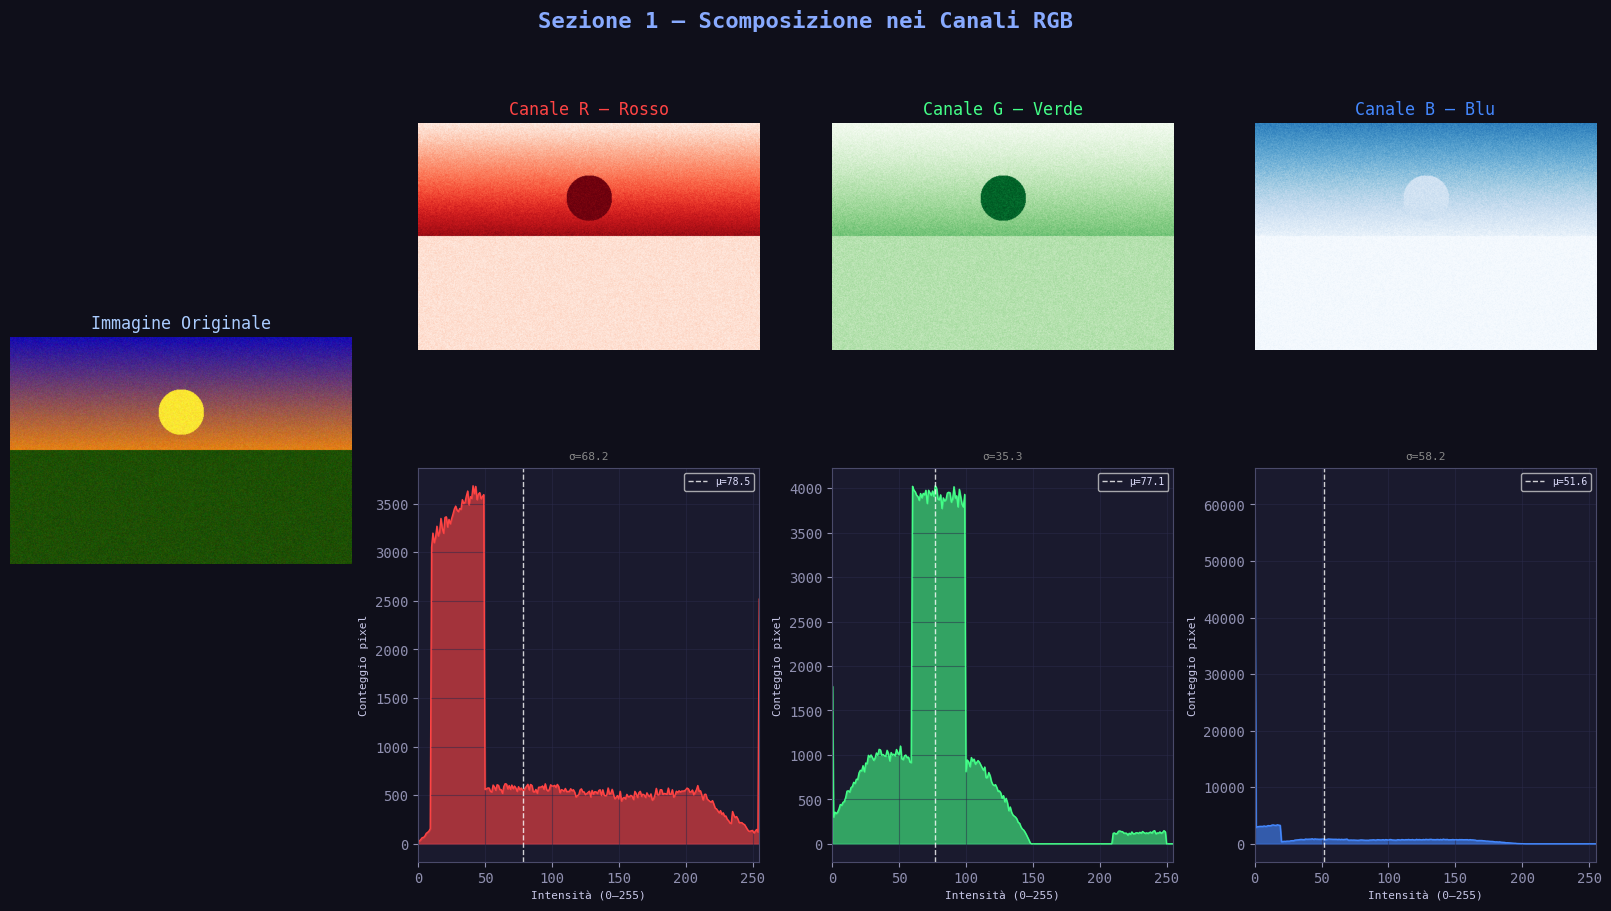

In [ ]:
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
fig.suptitle("Sezione 1 – Scomposizione nei Canali RGB",
             fontsize=16, fontweight="bold", color="#88aaff")

gs = gridspec.GridSpec(2, 4, figure=fig)

ax0 = fig.add_subplot(gs[:, 0])
ax0.imshow(img_rgb)
ax0.set_title("Immagine Originale", color="#aaccff")
ax0.axis("off")

for i, (nome, canale, cmap, col) in enumerate(zip(
        ["R – Rosso", "G – Verde", "B – Blu"],
        [R, G, B],
        ["Reds", "Greens", "Blues"],
        [COLORI_CANALI["R"], COLORI_CANALI["G"], COLORI_CANALI["B"]])):

    ax_img = fig.add_subplot(gs[0, i + 1])
    ax_img.imshow(canale, cmap=cmap, vmin=0, vmax=255)
    ax_img.set_title(f"Canale {nome}", color=col)
    ax_img.axis("off")

    ax_h = fig.add_subplot(gs[1, i + 1])
    hist  = calcola_istogramma(canale)
    ax_h.fill_between(range(256), hist, alpha=0.6, color=col)
    ax_h.plot(hist, color=col, linewidth=1)
    ax_h.axvline(canale.mean(), color="white", linestyle="--", linewidth=1,
                 alpha=0.8, label=f"μ={canale.mean():.1f}")
    ax_h.set_xlabel("Intensità (0–255)", fontsize=8)
    ax_h.set_ylabel("Conteggio pixel", fontsize=8)
    ax_h.set_xlim(0, 255)
    ax_h.set_title(f"σ={canale.std():.1f}", fontsize=8, color="#888")
    ax_h.legend(fontsize=7, loc="upper right")
    ax_h.grid(True)

plt.show()


## A cosa serve l'istogramma?

### 1. Diagnosi della qualità di acquisizione

Quando fotografi o acquisisci un'immagine, l'istogramma per canale ti dice subito se qualcosa è andato storto nella cattura:

- **Canale R saturato a destra** → overexposure sulle zone rosse (es. tramonto bruciato)
- **Canale B schiacciato a sinistra** → sottosposizione nelle ombre blu, perdi dettaglio
- **Canale G spostato rispetto agli altri** → dominante di colore, la scena appare "tinteggiata"

Le fotocamere reflex mostrano proprio questi istogrammi separati nel mirino per questo motivo: un istogramma globale (luminosità) può sembrare OK mentre un singolo canale è già clippato.

---

### 2. Correzione del bilanciamento del bianco

Un'area che dovrebbe essere bianca o grigia neutrale ha per definizione R = G = B. Se l'istogramma mostra i tre picchi sfasati tra loro, c'è uno sbilanciamento cromatico: puoi quantificarlo e correggerlo traslando i canali fino ad allinearli. È la base del **gray world assumption** usata nei software di editing (Lightroom, RawTherapee, ecc.).

---

### 3. Segmentazione e rilevamento oggetti per colore

In computer vision, se vuoi isolare oggetti di un certo colore (es. rilevare una sfera rossa in un frame video), l'istogramma per canale ti permette di identificare i range di intensità su cui applicare la sogliatura. Guardi il picco del canale R, definisci una maschera, e filtri. È più robusto che lavorare sull'immagine RGB grezza.

---

### 4. Compressione e ottimizzazione della LUT

Come discusso nella Lezione 2, nelle immagini a 8-bit indicizzate bisogna scegliere quali 256 colori mettere nella Color Lookup Table. L'istogramma per canale rivela dove si concentra la distribuzione cromatica: se il canale R ha un picco stretto intorno a 200, conviene allocare molti colori in quel range e pochi altrove. È la base degli algoritmi di quantizzazione del colore (median cut, k-means cromatico).

---

### 5. Imaging medico

In radiologia e microscopia, ogni canale può corrispondere a una modalità fisica diversa (es. fluorescenza multispettrale). L'istogramma del singolo canale guida il windowing: si seleziona il range di intensità di interesse clinico (es. dove si concentrano i tessuti patologici) e si estende a tutto il display, rendendo visibili dettagli altrimenti invisibili a occhio nudo.

---

### 6. Rilevamento di manipolazioni (forensics)

Se un'immagine è stata modificata o compressa in modo non uniforme, i canali R, G, B mostrano distribuzioni anomale: picchi troppo regolari, gap artificiali, distribuzioni asimmetriche che non compaiono nell'originale. L'analisi degli istogrammi per canale è uno degli strumenti base nell'image forensics.

---

In sintesi: l'istogramma globale dice *quanto* è luminosa un'immagine, ma non *perché*. Gli istogrammi per canale separano le cause — illuminazione, dominante di colore, saturazione selettiva — e permettono di agire in modo chirurgico invece che globale.

---
## ⬜ Sezione 2 – Analisi in Scala di Grigi

La conversione in scala di grigi usa i **pesi percettuali ITU-R BT.601**, che tengono conto della sensibilità dell'occhio umano ai diversi colori:

$$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$

Il verde ha peso maggiore perché il sistema visivo umano è più sensibile alla lunghezza d'onda verde.

Il grafico mostra anche la **CDF** (Cumulative Distribution Function), fondamentale per capire il funzionamento dell'equalizzazione.

> 💡 **Domanda:** cosa indica graficamente una CDF ripida in un intervallo ristretto di intensità?


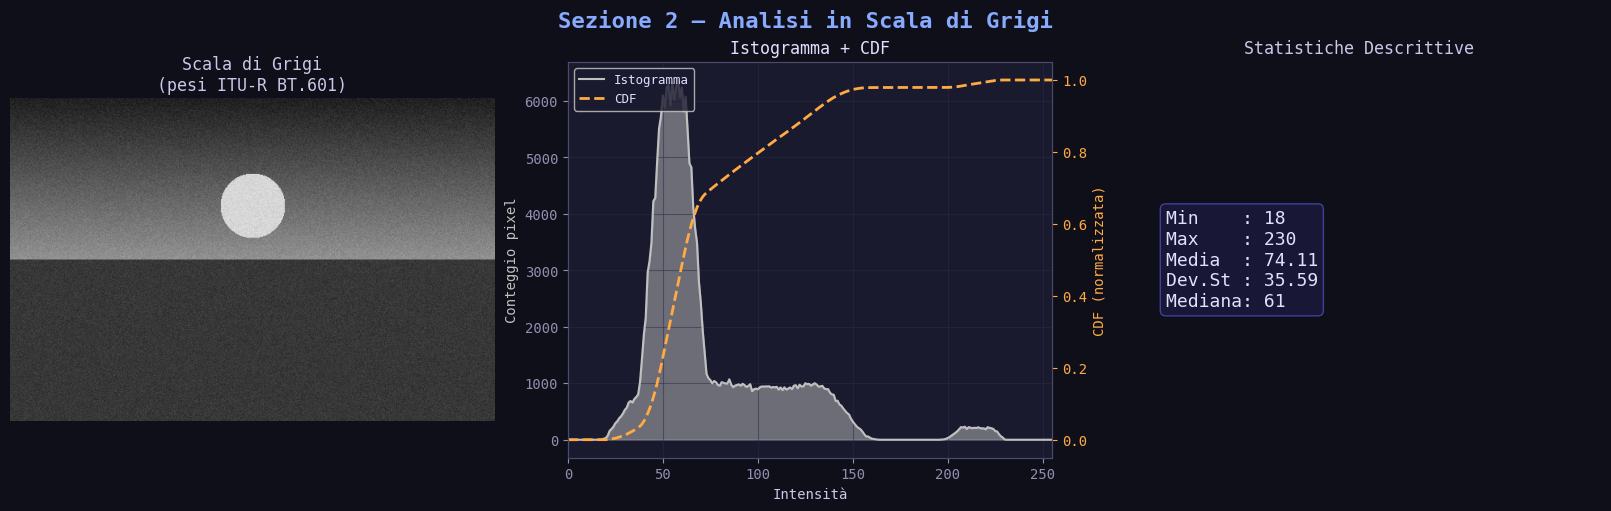

In [ ]:
# Conversione con pesi percettuali ITU-R BT.601
gray = np.dot(img_rgb[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

hist     = calcola_istogramma(gray)
cdf      = hist.cumsum()
cdf_norm = cdf / cdf.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle("Sezione 2 – Analisi in Scala di Grigi",
             fontsize=16, fontweight="bold", color="#88aaff")

axes[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Scala di Grigi\n(pesi ITU-R BT.601)", color="#c8c8e8")
axes[0].axis("off")

ax_h = axes[1]
ax_h.fill_between(range(256), hist, alpha=0.5, color=COLORI_CANALI["Gray"])
ax_h.plot(hist, color=COLORI_CANALI["Gray"], linewidth=1.5, label="Istogramma")
ax_h.set_xlim(0, 255)
ax_h.set_xlabel("Intensità")
ax_h.set_ylabel("Conteggio pixel", color=COLORI_CANALI["Gray"])
ax_h.set_title("Istogramma + CDF")
ax_h.grid(True)

ax_cdf = ax_h.twinx()
ax_cdf.plot(cdf_norm, color="#ffaa44", linewidth=2, linestyle="--", label="CDF")
ax_cdf.set_ylabel("CDF (normalizzata)", color="#ffaa44")
ax_cdf.tick_params(colors="#ffaa44")

lines  = ax_h.get_lines() + ax_cdf.get_lines()
labels = [l.get_label() for l in lines]
ax_h.legend(lines, labels, loc="upper left", fontsize=9)

stats_txt = (
    f"Min    : {gray.min()}\n"
    f"Max    : {gray.max()}\n"
    f"Media  : {gray.mean():.2f}\n"
    f"Dev.St : {gray.std():.2f}\n"
    f"Mediana: {np.median(gray):.0f}"
)
axes[2].text(0.1, 0.5, stats_txt, transform=axes[2].transAxes,
             fontsize=13, verticalalignment="center", family="monospace",
             color="#e0e0ff",
             bbox=dict(boxstyle="round", facecolor="#1a1a3a",
                       edgecolor="#4444aa", alpha=0.9))
axes[2].set_title("Statistiche Descrittive", color="#c8c8e8")
axes[2].axis("off")

plt.show()


## A cosa serve l'analisi in scala di grigi?


### 1. Ridurre la complessità computazionale

La maggior parte degli algoritmi di visione artificiale — rilevamento bordi (Canny, Sobel), corner detection (Harris), feature extraction (SIFT, ORB) — lavorano su un singolo piano di intensità. Passare a scala di grigi riduce i dati da elaborare di un fattore 3, senza perdere l'informazione strutturale (bordi, texture, forme) che è quella che interessa. La percezione della struttura di una scena è dominata dalla luminanza, non dalla crominanza — ed è esattamente per questo che i pesi ITU-R BT.601 (0.299·R + 0.587·G + 0.114·B) riflettono la sensibilità spettrale dell'occhio umano, con il verde che pesa quasi il doppio del rosso e sei volte il blu.

---

### 2. Analisi del contrasto locale e globale

L'istogramma in scala di grigi è la radiografia del contrasto dell'immagine:

- **Istogramma stretto e centrato** → immagine piatta, poco contrasto (es. foto in nebbia, documento scansionato male)
- **Istogramma bimodale** → immagine con sfondo chiaro e soggetto scuro (o viceversa), situazione ideale per la sogliatura automatica
- **Istogramma sbilanciato a sinistra** → immagine sottoesposta
- **Coda lunga a destra** → presenza di zone sovraesposte

Queste informazioni guidano le scelte di processing successive.

---

### 3. Sogliatura (thresholding) e segmentazione

Questa è probabilmente l'applicazione più diretta. L'algoritmo di Otsu, ad esempio, trova automaticamente la soglia ottimale cercando il punto dell'istogramma che minimizza la varianza intra-classe tra pixel chiari e scuri. Funziona sull'istogramma in scala di grigi e produce maschere binarie usate in OCR, analisi di documenti, microscopia cellulare, controllo qualità industriale.

---

### 4. Imaging medico

Radiografie, TAC e risonanze magnetiche sono intrinsecamente immagini in scala di grigi — ogni valore di intensità corrisponde a una proprietà fisica (densità del tessuto, coefficiente di attenuazione). L'istogramma permette il **windowing**: il radiologo seleziona il sottorange di intensità rilevante per una struttura anatomica (osso, polmone, tessuto molle hanno range diversi) e lo espande a tutto il display. Senza analisi dell'istogramma, dettagli clinicamente rilevanti rimarrebbero invisibili.

---

### 5. Compressione

Lo spazio YCbCr usato in JPEG e nei codec video separa la luminanza (Y) dalla crominanza (Cb, Cr) proprio perché l'occhio è molto più sensibile alle variazioni di luminanza che di colore. La Y è di fatto la scala di grigi dell'immagine. Il codec comprime Y con alta qualità e Cb/Cr con qualità ridotta (chroma subsampling 4:2:0), risparmiando bit senza che l'occhio se ne accorga. L'analisi dell'istogramma di Y determina quanto aggressiva può essere la quantizzazione.

---

### 6. Confronto e retrieval di immagini

L'istogramma in scala di grigi è uno dei descrittori globali più semplici per confrontare immagini. Due immagini con istogrammi simili hanno probabilmente contenuto visivo simile. È usato come feature di primo livello nei sistemi di image retrieval (ricerca per contenuto visivo) prima di applicare descrittori più costosi.

---

In sostanza: il colore è informazione semantica su *cosa* è nella scena, la scala di grigi è informazione strutturale su *dove* sono i bordi, le forme e le variazioni di luminosità. Quasi tutto il processing geometrico lavora su quest'ultima.

---
## 🌗 Sezione 3 – Equalizzazione dell'Istogramma

L'equalizzazione trasforma l'immagine in modo che la CDF risultante sia **approssimativamente lineare** (istogramma piatto). Il risultato è un utilizzo più uniforme dell'intero range di intensità.

### ⚠️ Attenzione – Equalizzazione su immagini RGB
Equalizzare i tre canali R, G, B **separatamente** può alterare il bilanciamento cromatico introducendo dominanti di colore indesiderate.

**Approccio corretto per immagini a colori:**
1. Convertire in spazio **HSV** o **YCbCr**
2. Equalizzare **solo** il canale di luminanza (V o Y)
3. Riconvertire in RGB

> 💡 **Osserva:** le immagini equalizzate mostrano più dettaglio nelle zone scure?  
> In quali applicazioni reali è più utile? (imaging medico, sorveglianza notturna, ecc.)


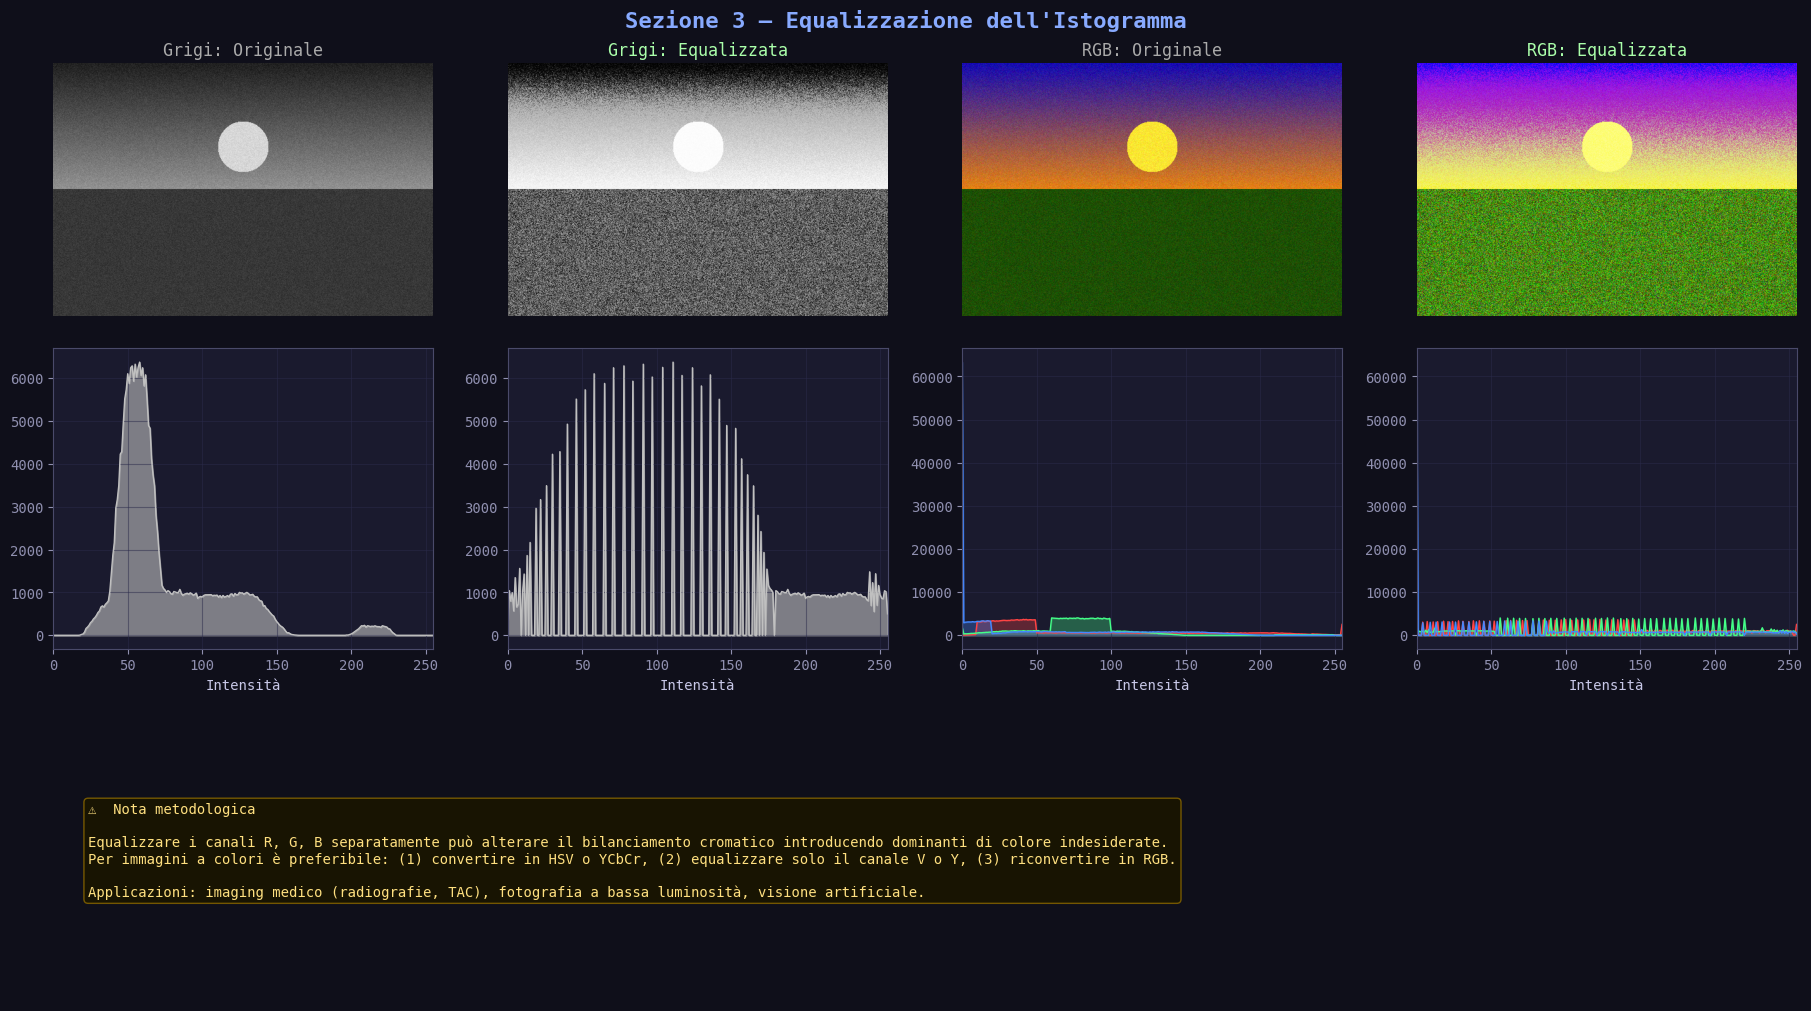

In [ ]:
gray_eq = equalizzazione_istogramma(gray)

R_eq = equalizzazione_istogramma(img_rgb[:, :, 0])
G_eq = equalizzazione_istogramma(img_rgb[:, :, 1])
B_eq = equalizzazione_istogramma(img_rgb[:, :, 2])
rgb_eq = np.stack([R_eq, G_eq, B_eq], axis=2)

fig = plt.figure(figsize=(18, 10), constrained_layout=True)
fig.suptitle("Sezione 3 – Equalizzazione dell'Istogramma",
             fontsize=16, fontweight="bold", color="#88aaff")

gs = gridspec.GridSpec(3, 4, figure=fig)

# Riga 0: immagini
for col, (im, titolo) in enumerate([
        (gray,    "Grigi: Originale"),
        (gray_eq, "Grigi: Equalizzata"),
        (img_rgb, "RGB: Originale"),
        (rgb_eq,  "RGB: Equalizzata")]):
    ax = fig.add_subplot(gs[0, col])
    kw = dict(cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else {}
    ax.imshow(im, **kw)
    col_title = "#aaaaaa" if "Orig" in titolo else "#aaffaa"
    ax.set_title(titolo, color=col_title)
    ax.axis("off")

# Riga 1: istogrammi grigi
for col, (canale, c_str) in enumerate([(gray, COLORI_CANALI["Gray"]),
                                        (gray_eq, COLORI_CANALI["Gray"])]):
    ax = fig.add_subplot(gs[1, col])
    h = calcola_istogramma(canale)
    ax.fill_between(range(256), h, alpha=0.6, color=c_str)
    ax.plot(h, color=c_str, linewidth=1)
    ax.set_xlim(0, 255); ax.grid(True)
    ax.set_xlabel("Intensità")

# Riga 1: istogrammi RGB
for col, (r, g, b) in enumerate([
        (img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]),
        (R_eq, G_eq, B_eq)]):
    ax = fig.add_subplot(gs[1, col + 2])
    for ch, c_str in zip([r, g, b],
                         [COLORI_CANALI["R"], COLORI_CANALI["G"], COLORI_CANALI["B"]]):
        h = calcola_istogramma(ch)
        ax.fill_between(range(256), h, alpha=0.3, color=c_str)
        ax.plot(h, color=c_str, linewidth=1)
    ax.set_xlim(0, 255); ax.grid(True)
    ax.set_xlabel("Intensità")

# Riga 2: nota metodologica
ax_note = fig.add_subplot(gs[2, :])
nota = (
    "⚠  Nota metodologica\n\n"
    "Equalizzare i canali R, G, B separatamente può alterare il bilanciamento cromatico "
    "introducendo dominanti di colore indesiderate.\n"
    "Per immagini a colori è preferibile: (1) convertire in HSV o YCbCr, "
    "(2) equalizzare solo il canale V o Y, (3) riconvertire in RGB.\n\n"
    "Applicazioni: imaging medico (radiografie, TAC), fotografia a bassa luminosità, visione artificiale."
)
ax_note.text(0.02, 0.5, nota, transform=ax_note.transAxes,
             fontsize=10, verticalalignment="center", color="#ffe080",
             bbox=dict(boxstyle="round", facecolor="#1a1500",
                       edgecolor="#806000", alpha=0.9))
ax_note.axis("off")
plt.show()



### L'intuizione: ridistribuire i pixel

Immagina di avere un'immagine sottoesposta: quasi tutti i pixel hanno valori bassi, compressi nell'intervallo 0–80 su 256 possibili. L'istogramma ha un grosso ammasso a sinistra e niente a destra. Stai "sprecando" la maggior parte del range disponibile.

Equalizzare significa **stirare** quella distribuzione in modo che i livelli di intensità siano usati in modo più uniforme su tutto il range 0–255. Non si aggiunge informazione che non c'era — si redistribuisce quella esistente in modo da renderla più leggibile.

La risposta breve è: **l'immagine equalizzata ha più contrasto, ma non necessariamente è più bella o più fedele alla realtà.**

---

### Cosa vedi concretamente

**Prima dell'equalizzazione** — immagine sottoesposta o a basso contrasto:
- Le zone d'ombra sono tutte ugualmente scure, i dettagli si perdono nel nero
- Le zone chiare sono tutte ugualmente luminose, i dettagli si perdono nel bianco
- L'occhio fatica a distinguere strutture vicine che differiscono di pochi livelli di intensità

**Dopo l'equalizzazione:**
- Quelle piccole differenze di intensità vengono amplificate e diventano visibili
- Zone che sembravano uniformemente scure rivelano texture, bordi, profondità
- Il contrasto percepito aumenta drasticamente

---

### Perché funziona a livello visivo

Il sistema visivo umano non percepisce l'intensità assoluta dei pixel — percepisce il **contrasto relativo** tra zone adiacenti. Due pixel con valori 10 e 12 sembrano identici. Gli stessi pixel rimappati a 0 e 55 sembrano chiaramente diversi. L'informazione era già lì, semplicemente compressa in un range troppo stretto per essere percepita.

È lo stesso principio per cui in una stanza buia gli occhi si adattano e cominciano a vedere dettagli che sembravano invisibili: il sistema visivo sta facendo internamente qualcosa di simile all'equalizzazione.

---

### I casi in cui l'equalizzazione peggiora la percezione

Non è sempre un miglioramento, e questo è importante capirlo.

**Amplificazione del rumore** — nelle zone uniformi (es. un cielo piatto, una parete bianca) ci sono piccole variazioni casuali di intensità dovute al sensore. Sono impercettibili nell'originale perché il loro range è stretto. Dopo equalizzazione quelle variazioni vengono amplificate esattamente come i dettagli utili, e il risultato è una texture granulosa fastidiosa dove prima c'era una superficie liscia.

**Aspetto innaturale** — una foto di un tramonto equalizzata perde la sua gamma tonale morbida. I colori sembrano posterizzati, le sfumature diventano salti bruschi. L'occhio riconosce immediatamente che qualcosa non va perché non corrisponde all'esperienza visiva del mondo reale.

**Perdita di livelli rari** — come visto nell'algoritmo, i livelli di intensità con pochissimi pixel collassano su quelli vicini. Se quei livelli corrispondevano a dettagli sottili ma significativi, quella informazione viene persa in modo irreversibile.

---

### La differenza rispetto allo stretching

Percettivamente lo stretching è più conservativo: aumenta il contrasto globale ma mantiene i rapporti tonali dell'immagine originale. Se un oggetto era il doppio più luminoso di un altro prima, lo è ancora dopo. Con l'equalizzazione questo non vale più — i rapporti vengono distorti perché la trasformazione è non lineare. L'immagine risultante può sembrare più "drammatica" ma meno realistica.

---

In sintesi: l'equalizzazione è uno strumento potente per **estrarre informazione nascosta**, ma va usata consapevolmente. In imaging medico è preziosa perché l'obiettivo è vedere il massimo dettaglio possibile. In fotografia artistica è quasi sempre sbagliata perché distrugge la naturalezza della scena.

---

### Come funziona tecnicamente

Lo strumento è la **CDF** (Cumulative Distribution Function): per ogni livello di intensità *r*, la CDF dice quanti pixel hanno intensità ≤ *r*. La trasformazione è:

$$T(r) = \lfloor 255 \cdot CDF(r) \rfloor$$

Se un valore di intensità è molto frequente (picco nell'istogramma), la CDF sale ripidamente in quel punto → quei pixel vengono "spalmati" su un range ampio nell'output. Se un valore è raro, la CDF sale poco → quei livelli vengono compressi o eliminati.

Il risultato ideale è una CDF lineare, che corrisponde a un istogramma piatto.

---

### A cosa serve concretamente

**Imaging medico** — è l'applicazione più importante. Una radiografia ha contrasto naturalmente basso: i tessuti molli differiscono di pochi livelli di intensità. Equalizzare amplifica queste differenze sottili, rendendo visibili strutture anatomiche che a occhio nudo sarebbero indistinguibili. È usato sistematicamente in TAC, mammografie, microscopia.

**Fotografia e ripresa in condizioni difficili** — immagini scattate in controluce, in ambienti notturni o in condizioni di nebbia hanno istogrammi compressi. L'equalizzazione recupera dettaglio nelle zone scure o nelle alte luci senza toccare manualmente curve e livelli.

**Visione artificiale e preprocessing** — prima di applicare algoritmi di rilevamento bordi, segmentazione o riconoscimento, equalizzare standardizza il contrasto dell'immagine in ingresso. Questo rende il sistema più robusto a variazioni di illuminazione: la stessa scena ripresa in momenti diversi della giornata produce immagini con istogrammi molto diversi, ma dopo equalizzazione diventano più simili.

**Sorveglianza e sicurezza** — telecamere in ambienti poco illuminati producono immagini buie con dettaglio perso nelle ombre. L'equalizzazione in tempo reale (spesso su chip dedicato) migliora la leggibilità dei frame senza aumentare l'esposizione fisica del sensore.

---

### Il limite principale

L'equalizzazione è **globale**: calcola la CDF sull'intera immagine e applica la stessa trasformazione a ogni pixel. Se l'immagine ha zone con contrasto molto diverso (es. una finestra luminosa in una stanza buia), la trasformazione globale può migliorare le ombre ma bruciare le alte luci, o viceversa.

Per questo esiste la **CLAHE** (Contrast Limited Adaptive Histogram Equalization): divide l'immagine in tile, equalizza localmente ciascuno, e interpola ai bordi per evitare artefatti. È lo standard in imaging medico moderno e in OpenCV è disponibile come funzione diretta.


## Algoritmo di equalizzazione

```
INPUT:  immagine in scala di grigi (valori 0–255)
OUTPUT: immagine equalizzata

─────────────────────────────────────────────
PASSO 1 — Calcola l'istogramma
─────────────────────────────────────────────

Per ogni livello i da 0 a 255:
    hist[i] = numero di pixel con intensità i

Esempio su immagine 4×4 (16 pixel totali):

    Intensità:  0   1   2   3   4   5   6   7
    hist:       2   3   0   4   1   3   2   1

─────────────────────────────────────────────
PASSO 2 — Calcola la CDF (somma cumulativa)
─────────────────────────────────────────────

cdf[0] = hist[0]
Per ogni i da 1 a 255:
    cdf[i] = cdf[i-1] + hist[i]

Continuando l'esempio:

    Intensità:  0   1   2   3   4   5   6   7
    hist:       2   3   0   4   1   3   2   1
    cdf:        2   5   5   9  10  13  15  16

    (l'ultimo valore è sempre uguale al numero totale di pixel)

─────────────────────────────────────────────
PASSO 3 — Normalizza la CDF su [0, 255]
─────────────────────────────────────────────

cdf_min   = primo valore di cdf maggiore di zero
n_pixel   = numero totale di pixel

Per ogni i da 0 a 255:
    lut[i] = ARROTONDA( 255 × (cdf[i] - cdf_min) / (n_pixel - cdf_min) )

Questa è la Look-Up Table di trasformazione.

Continuando l'esempio (cdf_min=2, n_pixel=16):

    i=0 → lut[0] = 255 × (2-2)  / (16-2) =   0
    i=1 → lut[1] = 255 × (5-2)  / (16-2) =  55
    i=2 → lut[2] = 255 × (5-2)  / (16-2) =  55  ← stesso di i=1 (nessun pixel aveva i=2)
    i=3 → lut[3] = 255 × (9-2)  / (16-2) = 127
    i=4 → lut[4] = 255 × (10-2) / (16-2) = 146
    i=5 → lut[5] = 255 × (13-2) / (16-2) = 200
    i=6 → lut[6] = 255 × (15-2) / (16-2) = 236
    i=7 → lut[7] = 255 × (16-2) / (16-2) = 255

─────────────────────────────────────────────
PASSO 4 — Applica la LUT a ogni pixel
─────────────────────────────────────────────

Per ogni pixel p nell'immagine:
    pixel_output = lut[pixel_input]

Ogni pixel viene rimappato secondo la tabella calcolata.
Non serve ricalcolare nulla: è una semplice consultazione.

─────────────────────────────────────────────
VERIFICA DELL'EFFETTO
─────────────────────────────────────────────

Prima:   0   1   2   3   4   5   6   7
Dopo:    0  55  55 127 146 200 236 255

I valori che prima erano compressi in [0,7]
ora occupano tutto il range [0, 255].
I livelli rari (i=2) collassano su quelli vicini:
è il prezzo da pagare — non si crea informazione nuova.

─────────────────────────────────────────────
COMPLESSITÀ
─────────────────────────────────────────────

Passo 1:  O(N)      N = numero di pixel
Passo 2:  O(256)    costante (solo 256 livelli)
Passo 3:  O(256)    costante
Passo 4:  O(N)      un accesso in tabella per pixel

Totale:   O(N)  →  lineare nel numero di pixel
          Molto efficiente, applicabile in tempo reale.
```